# Example likelihood calculations for photometric probes (WL, GCph, 2x2pt, and 3x2pt)

Currently implemented only for harmonic-space observables

In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# Import euclidlib for reading the Euclid data
import euclidlib as el

# Import cloelib for cosmology and theoretical predictions
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations

# Import cloelike for likelihood computations
from cloelike.EuclidLikelihood_photo_Cls import EuclidLikelihood_WL, EuclidLikelihood_GCph, EuclidLikelihood_2x2pt, EuclidLikelihood_3x2pt

# Avoid warnings for cleaner output 
np.seterr(divide='ignore', over='ignore', invalid='ignore') # Ignore divide by zero and overflow errors in numpy operations, which can occur in loglike calculation, it is annoying otherwise

/Users/guadalupecanasherrera/miniforge3/envs/cloe-org-env-v2026.1/lib/python3.12/site-packages/HMcode2020Emu
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

## Download Synthetic Data

We are currently developing homogeneous synthetic data vectors, mixing matrices, and covariance matrices that are compatible with [euclidlib](https://github.com/euclidlib/euclidlib) and adhere to the data format specifications used by the Euclid Science Ground Segment (LE3).


In [2]:
# Execute this cell to download the data for testing the likelihood calculations
data_downloaded = False

if data_downloaded == False:
    
    import requests
    
    # URLs of the files to be downloaded
    urls = {
        'nz_example.fits': 'https://zenodo.org/records/15092862/files/nz_example.fits',
        'mixmats_example.fits': 'https://zenodo.org/records/19071608/files/mixmats_example.fits',
        'synthetic_coupled_cells.fits': 'https://zenodo.org/records/19071608/files/synthetic_coupled_cells.fits',
        'covmat_2D.npz': 'https://zenodo.org/records/19071608/files/covmat_2D.npz'
    }
    
    
    # Function to download a file
    def download_file(url, filename):
        response = requests.get(url)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            print(f'{filename} downloaded successfully')
        else:
            print(f'Failed to download {filename}. Status code: {response.status_code}')
    
    # Download all files
    for filename, url in urls.items():
        download_file(url, filename)

nz_example.fits downloaded successfully
mixmats_example.fits downloaded successfully
synthetic_coupled_cells.fits downloaded successfully
covmat_2D.npz downloaded successfully


## Read the Data and Normalise $n(z)$

To begin working with the photometric observables, the first step involves reading the data and normalising the redshift distribution, $n(z)$.

> **Note**: You will need to have installed `euclidlib` version **v2025.2**. Version **v2025.1** is also compatible.

Ensure you have the necessary input files (e.g., redshift distributions, masks, and bias functions) and follow the loading routines provided in the `euclidlib.photo` module.


In [3]:
# Get n(z)
z_nz, nz_heracles = el.phz.redshift_distributions('nz_example.fits')

# Normalize and resample n(z) for both position and shear
myz = np.linspace(1e-4, 3.0, 100)
def normalize_and_resample(nz_dict, z_grid, z_target):
    nz_array = np.vstack([nz / integrate.trapezoid(nz, z_grid) for nz in nz_dict.values()])
    return np.array([np.interp(z_target, z_grid, nz) for nz in nz_array])

my_dndz_pos_norm = normalize_and_resample(nz_heracles, z_nz, myz)
my_dndz_she_norm = normalize_and_resample(nz_heracles, z_nz, myz)

In [4]:
# We read with euclidlib 
cls_data = el.le3.pk_wl.angular_power_spectra('synthetic_coupled_cells.fits')
mixmats = el.le3.pk_wl.mixing_matrices('mixmats_example.fits')

In [5]:
# Count entries in cls_data by probe pair
probe_pairs = [('SHE', 'SHE'), ('POS', 'SHE'), ('POS', 'POS')]

counts = {
    pair: sum(1 for k in cls_data.keys() if k[0] == pair[0] and k[1] == pair[1])
    for pair in probe_pairs
}

print(f"Total entries in cls_data: {len(cls_data)}")
for (a, b), n in counts.items():
    print(f"Entries for ({a}, {b}): {n}")

Total entries in cls_data: 78
Entries for (SHE, SHE): 21
Entries for (POS, SHE): 36
Entries for (POS, POS): 21


In [6]:
covmat_3x2pt = np.load("covmat_2D.npz")['Gauss']

In [7]:
covmat_WL = covmat_3x2pt[:672, :672]
covmat_GC = covmat_3x2pt[1824:, 1824:]
covmat_2x2pt = covmat_3x2pt[672:, 672:]

In [8]:
print(f"Covariance shapes:")
print(f"WL: {covmat_WL.shape}")
print(f"GC: {covmat_GC.shape}")
print(f"2x2pt: {covmat_2x2pt.shape}")
print(f"3x2pt: {covmat_3x2pt.shape}")

Covariance shapes:
WL: (672, 672)
GC: (672, 672)
2x2pt: (1824, 1824)
3x2pt: (2496, 2496)


In [9]:
cls_data["POS", "POS", 1, 1].ell

array([  10,   12,   15,   18,   21,   26,   31,   37,   44,   53,   64,
         77,   92,  110,  132,  158,  189,  226,  270,  323,  387,  462,
        553,  661,  790,  944, 1129, 1349, 1613, 1928, 2304, 2754],
      dtype='>i8')

In [10]:
def build_data(ell_key, cov, include_pos=False, include_she=False):
    data = {
        'cells': cls_data,
        'ells': cls_data[ell_key].ell,
        'z_arr': myz,
        'cov': cov,
        #'mixmat': mixmats,
    }
    if include_pos:
        data['dndz_pos'] = my_dndz_pos_norm
    if include_she:
        data['dndz_she'] = my_dndz_she_norm
    return data

def build_settings():
    scale_cuts = {key: [5, 3000] for key in cls_data}
    return {'n_ell_bins': 32, 'scale_cuts': scale_cuts}

# Build each dataset with correct dndz components
data_WL     = build_data(('SHE', 'SHE', 1, 1), covmat_WL,         include_she=True)
data_GC     = build_data(('POS', 'POS', 1, 1), covmat_GC,         include_pos=True)
data_2x2pt  = build_data(('POS', 'SHE', 1, 1), covmat_2x2pt,      include_pos=True, include_she=True)
data_3x2pt  = build_data(('POS', 'POS', 1, 1), covmat_3x2pt,      include_pos=True, include_she=True)

# Settings (same for all, built from cells_data structure)
settings_WL     = build_settings()
settings_GC     = build_settings()
settings_2x2pt  = build_settings()
settings_3x2pt  = build_settings()

In [11]:
import time

likelihood_classes = {
    'WL': EuclidLikelihood_WL,
    'GC': EuclidLikelihood_GCph,
    '2x2pt': EuclidLikelihood_2x2pt,
    '3x2pt': EuclidLikelihood_3x2pt,
}

data_dicts = {
    'WL': (data_WL, settings_WL),
    'GC': (data_GC, settings_GC),
    '2x2pt': (data_2x2pt, settings_2x2pt),
    '3x2pt': (data_3x2pt, settings_3x2pt),
}

like_tests = {}
loglike_results = {}

print("🔍 Timing log-likelihood initialisation (this only happens once) and displaying results:")

for label in ['WL', 'GC', '2x2pt', '3x2pt']:
    print(f"\n📊 {label} loglike:")
    data, settings = data_dicts[label]
    cls = likelihood_classes[label]

    start = time.time()
    like_tests[label] = cls(
        data=data,
        settings=settings,
        Background=CAMBBackground,
        LinPerturbations=HMemuLinearPerturbations,
        NonLinPerturbations=HMemuNonLinearPerturbations,
        mode='decoupled'
    )
    end = time.time()

    print(f"⏱️ Time elapsed ({label}): {end - start:.3f} seconds")


🔍 Timing log-likelihood initialisation (this only happens once) and displaying results:

📊 WL loglike:
⏱️ Time elapsed (WL): 0.000 seconds

📊 GC loglike:
⏱️ Time elapsed (GC): 0.000 seconds

📊 2x2pt loglike:
⏱️ Time elapsed (2x2pt): 0.000 seconds

📊 3x2pt loglike:
⏱️ Time elapsed (3x2pt): 0.000 seconds


In [12]:
# These are the default parameters used to generate the synthetic data, therefore, the log-likelihood should be close to zero.
default_pars = {'H0':70,'Omega_cdm0':0.25,'Omega_b0':0.05,'ns':0.96,'As':2.e-9,
                'w0':-1,'wa':0, 'Omega_k0':0,'mnu':0.06,'gamma_MG':0.545, 'N_mnu': 1, 
                'log10TAGN': 7.8,
                'AIA': 1.72, 'CIA': 0.0134, 'EtaIA':-0.41,
                'b1_photo_poly0': 1., 'b1_photo_poly1': 0.,
                'b1_photo_poly2': 0.0, 'b1_photo_poly3': 0.,
                'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
                'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
                'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
                'dz_pos_1': 0.0, 'dz_pos_2': 0.0,
                'dz_pos_3': 0.0, 'dz_pos_4': 0.0,
                'dz_pos_5': 0.0, 'dz_pos_6': 0.0,
                'multiplicative_bias_1': 0.0, 'multiplicative_bias_2': 0.0,
                'multiplicative_bias_3': 0.0, 'multiplicative_bias_4': 0.0,
                'multiplicative_bias_5': 0.0, 'multiplicative_bias_6': 0.0,
                'dz_shear_1': 0.0, 'dz_shear_2': 0.0,
                'dz_shear_3': 0.0, 'dz_shear_4': 0.0,
                'dz_shear_5': 0.0, 'dz_shear_6': 0.0}

You can always retrieve the theoretical prediction computed during the $\chi^2$ calculation and the derived parameters such as (in dictionary shape):

In [13]:
# Dictionary of pretty names for output
from unittest import result


labels_pretty = {
    'WL': "Weak Lensing (WL)",
    'GC': "Photometric Angular Galaxy Clustering (GC)",
    '2x2pt': "2x2pt",
    '3x2pt': "3x2pt"
}

print("⏱️ Timing log-likelihood evaluations and displaying results:")

loglike_results = {}

for label in [
              'WL', 
              'GC', 
              '2x2pt', 
              '3x2pt'
              ]:
    print(f"\n📊 {labels_pretty[label]} loglike:")
    start = time.time()
    result = like_tests[label].loglike(default_pars)
    elapsed = time.time() - start
    loglike_results[label] = result
    print(f"✅ Returned value ({label}): {result}")
    print(f"⏱️ Time elapsed ({label}): {elapsed:.3f} seconds")

⏱️ Timing log-likelihood evaluations and displaying results:

📊 Weak Lensing (WL) loglike:
✅ Returned value (WL): -15102.41429907317
⏱️ Time elapsed (WL): 3.807 seconds

📊 Photometric Angular Galaxy Clustering (GC) loglike:
✅ Returned value (GC): -73541.93402202494
⏱️ Time elapsed (GC): 0.814 seconds

📊 2x2pt loglike:
✅ Returned value (2x2pt): -82047.65615838305
⏱️ Time elapsed (2x2pt): 0.356 seconds

📊 3x2pt loglike:
✅ Returned value (3x2pt): -84358.18113740307
⏱️ Time elapsed (3x2pt): 0.651 seconds


You can always retrieve the theoretical prediction computed during the $\chi^2$ calculation and the derived parameters such as (in dictionary shape):

In [14]:
print(like_tests['WL'].theory_prediction)
print(like_tests['WL'].derived)

{('SHE', 'SHE', 1, 1): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 1, 2): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 1, 3): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 1, 4): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 1, 5): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 1, 6): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 2, 2): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 2, 3): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 2, 4): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 2, 5): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 2, 6): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 3, 3): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 3, 4): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 3, 5): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 3, 6): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 4, 4): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 4, 5): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 4, 6): AngularPowerSpectrum(axis=(2,)), ('SHE', '

## Exploring the Parameter Space

This section illustrates how we explore the dependence of photometric observables on the cold dark matter density parameter, $\Omega_{\rm cdm} h^2$. We scan a range of values and evaluate the likelihood for each photometric probe: Weak Lensing (WL), Galaxy Clustering (GC), 2x2pt (GC + GGL), and 3x2pt.

The likelihoods are computed using the corresponding Euclid likelihood classes, and we normalize each resulting curve to its maximum value for easier visual comparison. A vertical dashed line indicates a fiducial $\Omega_{\rm cdm} h^2$ value (e.g., the best fit).

We use `tqdm` to visually track the progress of likelihood evaluations for each probe.


🔄 Scanning over $H_0$ for WL


WL: 100%|███████████████████████████████████████| 50/50 [00:03<00:00, 12.79it/s]



🔄 Scanning over $H_0$ for GC


GC: 100%|███████████████████████████████████████| 50/50 [00:03<00:00, 15.99it/s]



🔄 Scanning over $H_0$ for 2x2pt


2x2pt: 100%|████████████████████████████████████| 50/50 [00:06<00:00,  7.40it/s]



🔄 Scanning over $H_0$ for 3x2pt


3x2pt: 100%|████████████████████████████████████| 50/50 [00:10<00:00,  4.92it/s]


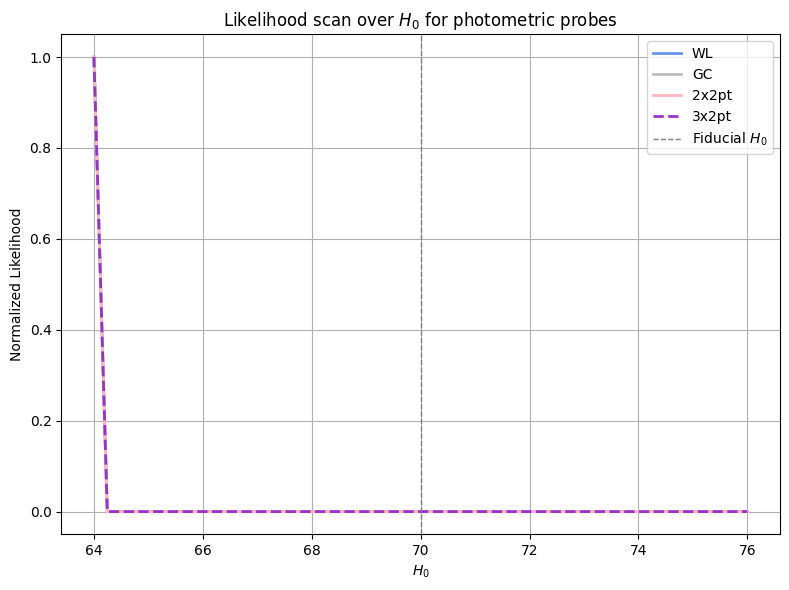

In [15]:
## Exploration of the parameter space
from tqdm import tqdm

# Define the range of H0 values to scan
H0 = np.linspace(64, 76, 50)

# Define colors and linestyles per probe
colors = {'WL': 'cornflowerblue', 'GC': 'silver', '2x2pt': 'lightpink', '3x2pt': 'darkorchid'}
linestyles = {'WL': '-', 'GC': '-', '2x2pt': '-', '3x2pt': '--'}

# Prepare the figure
plt.figure(figsize=(8, 6))

for label in ['WL', 'GC', '2x2pt', '3x2pt']:
    print(f"\n🔄 Scanning over $H_0$ for {label}")
    likelihood_curve = []

    for hi in tqdm(H0, desc=f"{label}", ncols=80):
        default_pars['H0'] = hi
        ll = like_tests[label].loglike(default_pars)
        likelihood_curve.append(ll)

    # Convert log-likelihoods to likelihoods (exp) and normalize
    likelihood_curve = np.exp(np.array(likelihood_curve) - np.max(likelihood_curve))

    # Plot with custom color and linestyle
    plt.plot(H0, likelihood_curve, label=label, color=colors[label], linestyle=linestyles[label], lw=2)

# Reset default_pars H0 to fiducial value
default_pars['H0'] = 70.0
plt.axvline(x=70.0, color='gray', linestyle='--', lw=1, label='Fiducial $H_0$')

plt.xlabel(r'$H_0$')
plt.ylabel('Normalized Likelihood')
plt.title('Likelihood scan over $H_0$ for photometric probes')
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.xlim(69.95, 70.05)
plt.show()